In [1]:
!pip install lightning-utilities
!pip install torchmetrics --no-deps
!pip install torchinfo --no-deps
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.1/54.1 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.1/323.1 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 5.0 MB/s eta 0:00:00


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torchvision
from torchvision import models
from torchvision.transforms import v2
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader
import gradio as gr

from torchmetrics import Accuracy, Precision, Recall, F1Score, ConfusionMatrix
from torchinfo import summary

In [3]:
device = "cuda" if torch.cuda.is_available()\
          else "mps" if torch.mps.is_available()\
          else "cpu"
print("Device:" , device)

Device: cuda


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!unzip "/content/drive/MyDrive/chest_xray.zip" -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/chest_xray/train/NORMAL/IM-0435-0001.jpeg  
  inflating: /content/chest_xray/train/NORMAL/IM-0437-0001-0001.jpeg  
  inflating: /content/chest_xray/train/NORMAL/IM-0437-0001-0002.jpeg  
  inflating: /content/chest_xray/train/NORMAL/IM-0437-0001.jpeg  
  inflating: /content/chest_xray/train/NORMAL/IM-0438-0001.jpeg  
  inflating: /content/chest_xray/train/NORMAL/IM-0439-0001-0001.jpeg  
  inflating: /content/chest_xray/train/NORMAL/IM-0439-0001-0002.jpeg  
  inflating: /content/chest_xray/train/NORMAL/IM-0439-0001.jpeg  
  inflating: /content/chest_xray/train/NORMAL/IM-0440-0001.jpeg  
  inflating: /content/chest_xray/train/NORMAL/IM-0441-0001.jpeg  
  inflating: /content/chest_xray/train/NORMAL/IM-0442-0001.jpeg  
  inflating: /content/chest_xray/train/NORMAL/IM-0444-0001.jpeg  
  inflating: /content/chest_xray/train/NORMAL/IM-0445-0001.jpeg  
  inflating: /content/chest_xray/train/NORMAL/IM-0446-0001.jpeg  
  inf

# Defining transforms

In [6]:
# data augmentation for train
train_transform = v2.Compose([
  v2.ColorJitter(brightness=0.3, contrast=0.5, saturation=0.5), # Adjust color
  v2.RandomHorizontalFlip(p=0.5), # Random horizontal flip
  v2.RandomResizedCrop(size=224, scale=(0.5, 1.0)), # Random crop and resize
  v2.ToImage(), # PyTorch Image format
  v2.ToDtype(torch.float32, scale=True), # Convert to tensor
  v2.Normalize(mean=[0.485, 0.456, 0.406],
               std=[0.229, 0.224, 0.225]), # Normalize
])

In [7]:
# data augmentation for validation and test
test_transform = v2.Compose([
  v2.Resize((224, 224)), # resize image to 224
  v2.ToImage(), # PyTorch Image format
  v2.ToDtype(torch.float32, scale=True), # Convert to tensor
  v2.Normalize(mean=[0.485, 0.456, 0.406],
               std=[0.229, 0.224, 0.225]), # Normalize
])

# Load datasets

In [8]:
# Point to original train directory (contains ALL images)
root = "/content/chest_xray/train"
full_dataset = ImageFolder(root, transform=train_transform)  # Apply transform here

In [9]:
from torch.utils.data import random_split

# Calculate sizes (e.g., 80/10/10 split)
total_size = len(full_dataset)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

# Split dataset
train_data, val_data, test_data = random_split(full_dataset, [train_size, val_size, test_size])

In [10]:
# DataLoaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

In [11]:
print(len(train_data))

4172


In [12]:
print(len(val_data))

521


In [13]:
print(len(test_data))

523


In [14]:
class_names = full_dataset.classes
print("Classes:", class_names)

Classes: ['NORMAL', 'PNEUMONIA']


# Defining four models

Custom CNN

In [15]:
custom_model = nn.Sequential(
    # Block 1
    nn.LazyConv2d(32, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),

    # Block 2
    nn.LazyConv2d(64, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),

    # Block 3
    nn.LazyConv2d(128, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),

    # Block 4 (Extra Layer)
    nn.LazyConv2d(256, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(256),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),

    # Fully connected layers
    nn.Flatten(),
    nn.LazyLinear(512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.LazyLinear(256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.LazyLinear(2)  # 2 classes: Pneumonia, Normal
).to(device)


DenSet121

In [16]:
from torchvision.models import densenet121

densenet = models.densenet121(weights='IMAGENET1K_V1')

for param in densenet.features.parameters():
    param.requires_grad = False

# Define num_class with the number of classes (2 in this case)
num_class = 2

densenet.classifier = nn.Sequential(
    nn.Linear(densenet.classifier.in_features, 128),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(128, num_class)) # Now using the defined num_class variable

densenet = densenet.to(device)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 106MB/s]


EfficientNet-B0

In [17]:
from torchvision.models import efficientnet_b0

efficientnet = models.efficientnet_b0(weights='IMAGENET1K_V1')

for param in efficientnet.features.parameters():
    param.requires_grad = False
efficientnet.classifier = nn.Sequential(
    nn.Linear(efficientnet.classifier[1].in_features, 128),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(128, num_class))

efficientnet = efficientnet.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 97.3MB/s]


VGG16

In [18]:
vgg16 = models.vgg16(weights='IMAGENET1K_V1')

for param in vgg16.features.parameters():
    param.requires_grad = False

vgg16.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, num_class))

vgg16 = vgg16.to(device)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:03<00:00, 152MB/s] 


ResNet18

In [19]:
resnet18 = models.resnet18(weights='IMAGENET1K_V1')

for param in resnet18.parameters():
    param.requires_grad = False
resnet18.fc = nn.Sequential(
    nn.Linear(resnet18.fc.in_features, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, num_class))

resnet18 = resnet18.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 163MB/s]


In [20]:
print(custom_model, densenet, efficientnet, vgg16, resnet18)

Sequential(
  (0): LazyConv2d(0, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): LazyConv2d(0, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): LazyConv2d(0, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU()
  (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (12): LazyConv2d(0, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (14): ReLU()
  (15): MaxPool2d(kernel_

# Train Function

In [21]:
def train_model(model, optimizer, name="Model", epochs=10, patience=3):
    criteria = nn.CrossEntropyLoss()
    acc = Accuracy(task="multiclass", num_classes=2).to(device)
    val_acc = Accuracy(task="multiclass", num_classes=2).to(device)

    best_val_acc = 0
    patience_counter = 0
    best_weights = None

    print(f"\nTraining [{name}]...\n")

    train_accuracies = []
    val_accuracies = []
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        acc.reset()
        total_loss = 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criteria(outputs, labels)
            loss.backward()
            optimizer.step()
            acc.update(outputs, labels)
            total_loss += loss.item()

        train_score = acc.compute().item()
        train_accuracies.append(train_score)
        train_losses.append(total_loss / len(train_loader))

        model.eval()
        val_acc.reset()
        val_total_loss = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criteria(outputs, labels)
                val_acc.update(outputs, labels)
                val_total_loss += loss.item()

        val_score = val_acc.compute().item()
        val_accuracies.append(val_score)
        val_losses.append(val_total_loss / len(val_loader))

        print(f"Epoch {epoch+1}: Train Acc = {train_score:.4f} | Val Acc = {val_score:.4f} | Train Loss = {train_losses[-1]:.4f} | Val Loss = {val_losses[-1]:.4f}")

        # Early stopping
        if val_score > best_val_acc:
            best_val_acc = val_score
            best_weights = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    # Load best weights
    if best_weights:
        model.load_state_dict(best_weights)

    print(f"\n[{name}] training complete.\n")
    return model, train_accuracies, val_accuracies, train_losses, val_losses

In [22]:
# 1. Custom CNN (use lower LR for stability with deeper custom nets)
custom_optimizer = torch.optim.Adam(custom_model.parameters(), lr=0.0001, weight_decay=0.00001)

# 2. ResNet18 (usually fine-tuned with a standard LR)
resnet_optimizer = torch.optim.Adam(resnet18.parameters(), lr=0.001)

# 3. DenseNet121
densenet_optimizer = torch.optim.Adam(densenet.parameters(), lr=0.001)

# 4. EfficientNet
efficientnet_optimizer = torch.optim.Adam(efficientnet.parameters(), lr=0.001)

# 5. VGG16
vgg_optimizer = torch.optim.Adam(vgg16.parameters(), lr=0.001)




```
# This is formatted as code
```

# Train all models

In [23]:
densenet_model = densenet # Assign densenet to densenet_model
resnet_model = resnet18 # Assign resnet18 to resnet_model
# efficientnet and vgg are already defined

# Train all models
custom_model, custom_train_acc, custom_val_acc, custom_train_loss, custom_val_loss = train_model(
    custom_model, custom_optimizer, name="Custom CNN", epochs=50)

resnet_model, resnet_train_acc, resnet_val_acc, resnet_train_loss, resnet_val_loss = train_model(
    resnet_model, resnet_optimizer, name="ResNet18")

densenet_model, densenet_train_acc, densenet_val_acc, densenet_train_loss, densenet_val_loss = train_model(
    densenet_model, densenet_optimizer, name="DenseNet121")

efficientnet, eff_train_acc, eff_val_acc, eff_train_loss, eff_val_loss = train_model(
    efficientnet, efficientnet_optimizer, name="EfficientNet")

vgg16, vgg_train_acc, vgg_val_acc, vgg_train_loss, vgg_val_loss = train_model(
    vgg16, vgg_optimizer, name="VGG16")



Training [Custom CNN]...

Epoch 1: Train Acc = 0.8231 | Val Acc = 0.9079 | Train Loss = 0.4125 | Val Loss = 0.2435
Epoch 2: Train Acc = 0.8730 | Val Acc = 0.8964 | Train Loss = 0.3116 | Val Loss = 0.2726
Epoch 3: Train Acc = 0.8921 | Val Acc = 0.8906 | Train Loss = 0.2664 | Val Loss = 0.2417
Epoch 4: Train Acc = 0.9077 | Val Acc = 0.9175 | Train Loss = 0.2311 | Val Loss = 0.2251
Epoch 5: Train Acc = 0.8981 | Val Acc = 0.9251 | Train Loss = 0.2461 | Val Loss = 0.1997
Epoch 6: Train Acc = 0.9137 | Val Acc = 0.9002 | Train Loss = 0.2157 | Val Loss = 0.2328
Epoch 7: Train Acc = 0.9190 | Val Acc = 0.9136 | Train Loss = 0.2070 | Val Loss = 0.2023
Epoch 8: Train Acc = 0.9175 | Val Acc = 0.9060 | Train Loss = 0.2087 | Val Loss = 0.2069
Early stopping at epoch 8

[Custom CNN] training complete.


Training [ResNet18]...

Epoch 1: Train Acc = 0.8483 | Val Acc = 0.8061 | Train Loss = 0.3600 | Val Loss = 0.4135
Epoch 2: Train Acc = 0.8802 | Val Acc = 0.9098 | Train Loss = 0.2926 | Val Loss = 0.216

In [24]:
import matplotlib.pyplot as plt

def plot_training_curves(train_loss, val_loss, train_acc, val_acc, model_name):
    plt.figure(figsize=(10, 4))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(train_loss, label="Train", color='blue')
    plt.plot(val_loss, label="Validation", color='red')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Loss Curve")
    plt.legend()
    plt.grid(True)

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(train_acc, label="Train", color='blue')
    plt.plot(val_acc, label="Validation", color='red')
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Curve")
    plt.legend()
    plt.grid(True)

    plt.suptitle(f"Training Curves - {model_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

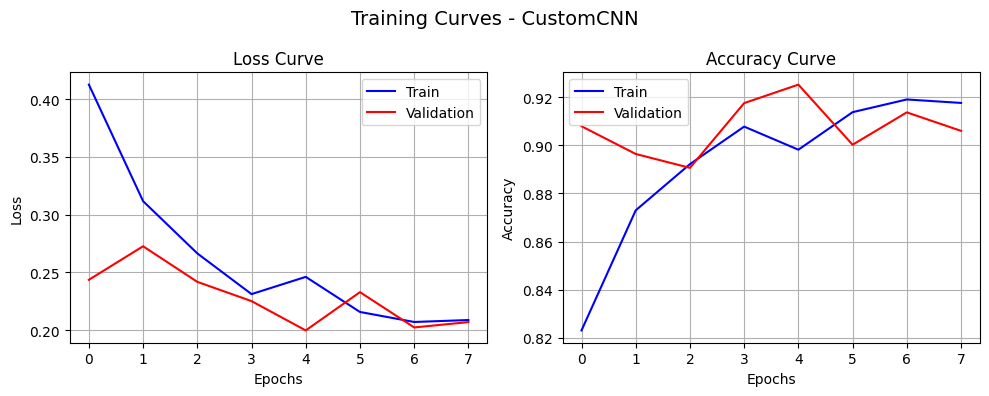

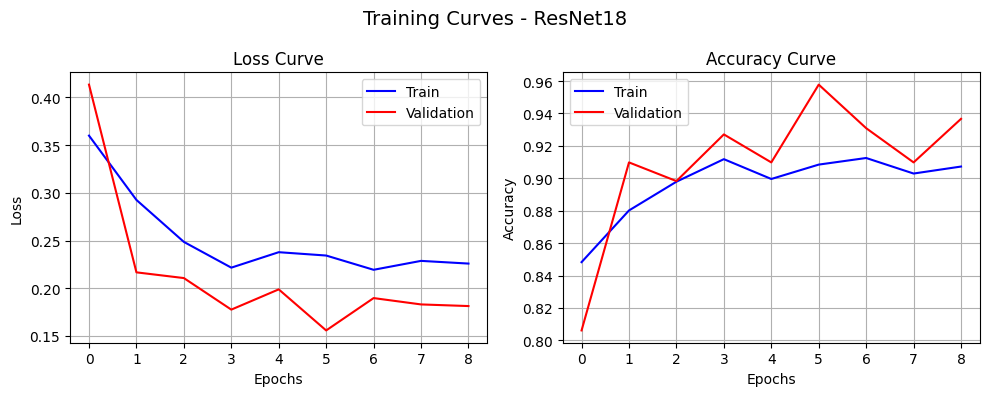

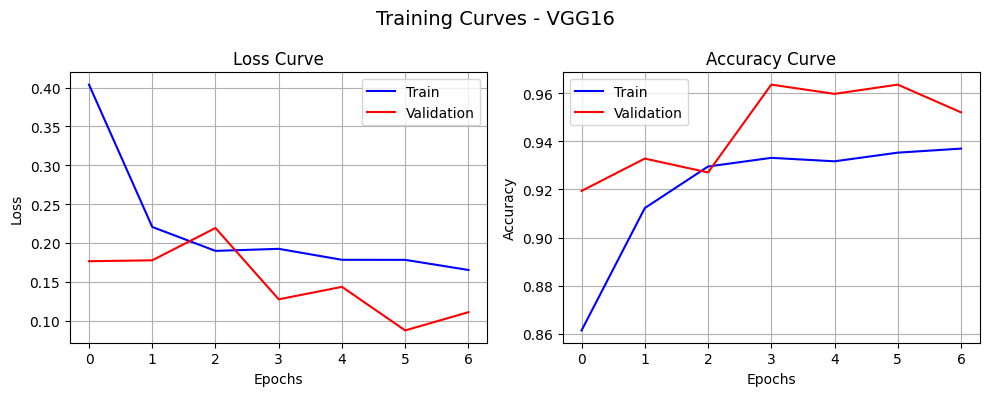

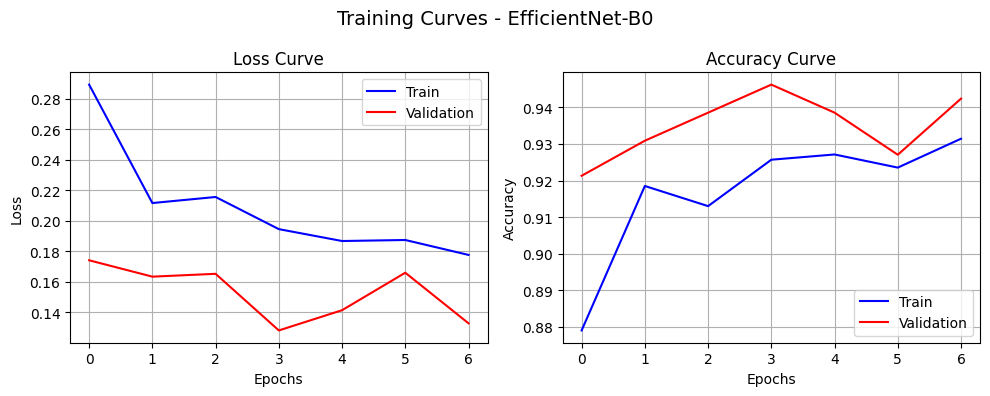

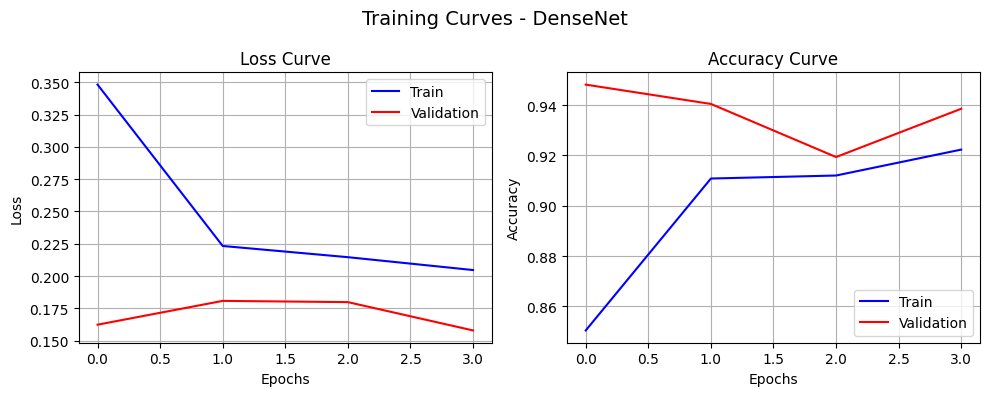

In [25]:
plot_training_curves(custom_train_loss, custom_val_loss, custom_train_acc, custom_val_acc, "CustomCNN")
plot_training_curves(resnet_train_loss, resnet_val_loss, resnet_train_acc, resnet_val_acc, "ResNet18")
plot_training_curves(vgg_train_loss, vgg_val_loss, vgg_train_acc, vgg_val_acc, "VGG16")
plot_training_curves(eff_train_loss, eff_val_loss, eff_train_acc, eff_val_acc, "EfficientNet-B0")
plot_training_curves(densenet_train_loss, densenet_val_loss, densenet_train_acc, densenet_val_acc, "DenseNet")


In [26]:
#def plot_training_curves(train_acc, val_acc, name):
    #plt.figure(figsize=(6, 4))
    #plt.plot(train_acc, label="Train Accuracy")
    #plt.plot(val_acc, label="Validation Accuracy")
    #plt.title(f"Training Curve - {name}")
    #plt.xlabel("Epoch")
    #plt.ylabel("Accuracy")
    #plt.legend()
    #plt.grid(True)
    #plt.show()

In [27]:
#plot_training_curves(densenet_train_acc, densenet_val_acc, "DenseNet121")
#plot_training_curves(resnet_train_acc, resnet_val_acc, "ResNet18")
#plot_training_curves(eff_train_acc, eff_val_acc, "EfficientNet")
#plot_training_curves(vgg_train_acc, vgg_val_acc, "VGG16")

# Evaluation function

# Evaluate all models

In [28]:
def evaluate_model(model, name="Model"):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            pred = torch.argmax(outputs, dim=1)
            preds.extend(pred.cpu().numpy())
            targets.extend(labels.cpu().numpy())

    preds = torch.tensor(preds)
    targets = torch.tensor(targets)

    acc = Accuracy(task='multiclass', num_classes=2)
    prec = Precision(task='multiclass', num_classes=2)
    rec = Recall(task='multiclass', num_classes=2)
    f1 = F1Score(task='multiclass', num_classes=2)

    print(f"Results for {name}:")
    print("Accuracy:", acc(preds, targets).item())
    print("Precision:", prec(preds, targets).item())
    print("Recall:", rec(preds, targets).item())
    print("F1 Score:", f1(preds, targets).item())

    cm = ConfusionMatrix(task='multiclass', num_classes=2)(preds, targets)
    plt.figure(figsize=(6, 4))
    # Pass the confusion matrix 'cm' to the 'data' argument
    sns.heatmap(cm, cmap="Blues", annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

Results for CustomCNN:
Accuracy: 0.923518180847168
Precision: 0.923518180847168
Recall: 0.923518180847168
F1 Score: 0.923518180847168


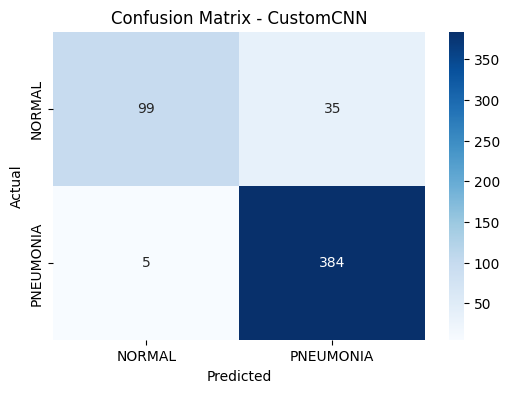

Results for DenseNet121:
Accuracy: 0.9311663508415222
Precision: 0.9311663508415222
Recall: 0.9311663508415222
F1 Score: 0.9311663508415222


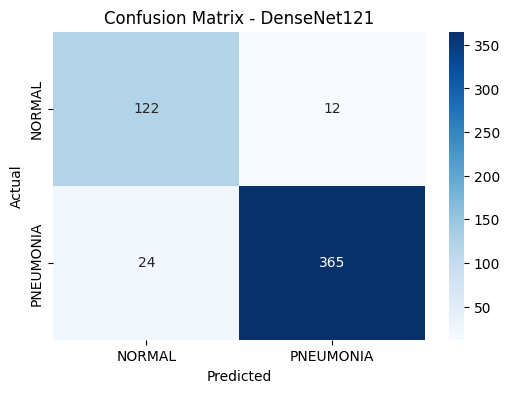

Results for ResNet18:
Accuracy: 0.9254302382469177
Precision: 0.9254302382469177
Recall: 0.9254302382469177
F1 Score: 0.9254302382469177


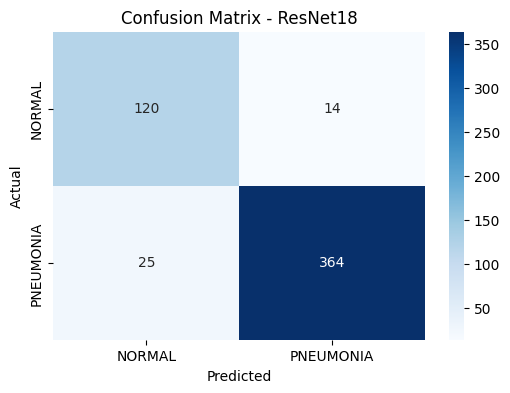

Results for EfficientNet:
Accuracy: 0.9369024634361267
Precision: 0.9369024634361267
Recall: 0.9369024634361267
F1 Score: 0.9369024634361267


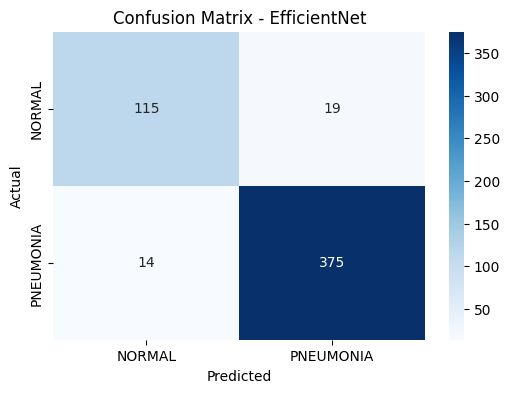

Results for VGG16:
Accuracy: 0.9579349756240845
Precision: 0.9579349756240845
Recall: 0.9579349756240845
F1 Score: 0.9579349756240845


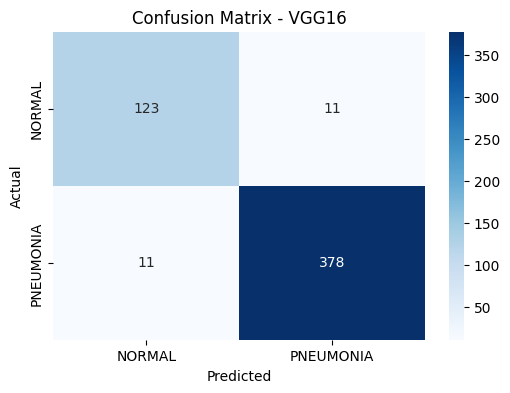

In [29]:
evaluate_model(custom_model, name="CustomCNN") # Call with 'model' and 'name' only
evaluate_model(densenet_model, name="DenseNet121")
evaluate_model(resnet_model, name="ResNet18")
evaluate_model(efficientnet, name="EfficientNet")
evaluate_model(vgg16, name="VGG16")

In [30]:
def plot_single_roc(model, name):
    model.eval()
    preds, targets = [], []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)[:, 1]  # class 1: Pneumonia
            preds.extend(probs.cpu().numpy())
            targets.extend(labels.cpu().numpy())

    from sklearn.metrics import roc_curve, auc
    fpr, tpr, _ = roc_curve(targets, preds)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"AUC-ROC Curve: {name}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

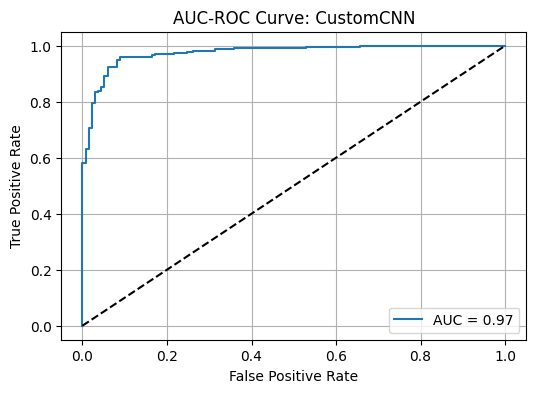

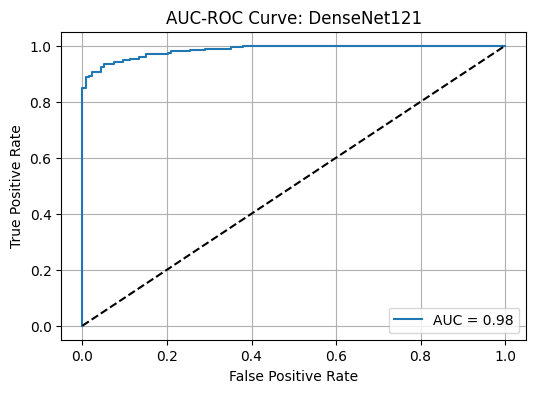

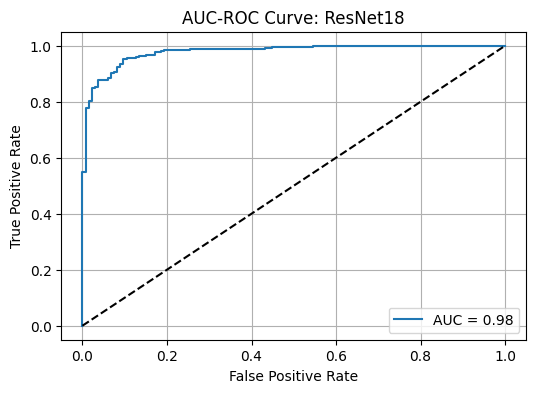

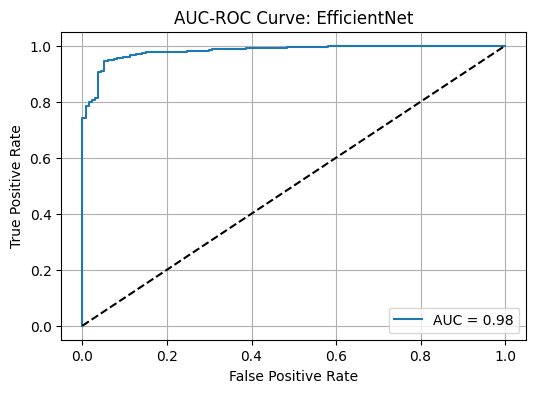

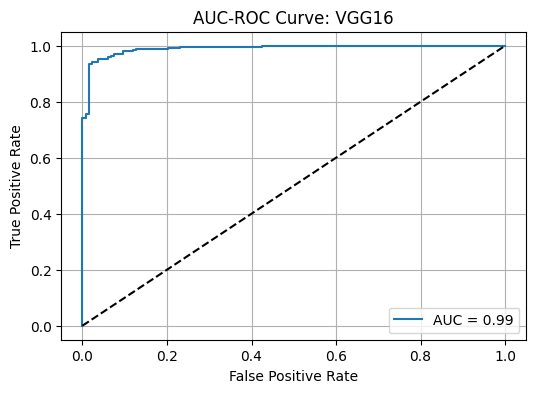

In [31]:
plot_single_roc(custom_model, "CustomCNN")
plot_single_roc(densenet_model, "DenseNet121")
plot_single_roc(resnet_model, "ResNet18")
plot_single_roc(efficientnet, "EfficientNet")
plot_single_roc(vgg16, "VGG16")

# Gradio

In [32]:
# Ensure models are in eval mode
custom_model.eval()
densenet_model.eval()
resnet_model.eval()
efficientnet.eval()
vgg16.eval()

# Use test_transform for Gradio inference
transform = test_transform

# Model selector function
def classify_image(image, model_choice):
    image = image.convert("RGB")
    img = transform(image).to(device).unsqueeze(0)

    if model_choice == "DenseNet121":
        model = densenet_model
    elif model_choice == "ResNet18":
        model = resnet_model
    elif model_choice == "EfficientNet":
        model = efficientnet
    elif model_choice == "VGG16":
        model = vgg16
    elif model_choice == "CustomCNN":
        model = custom_model
    else:
        return {"Error": "Invalid model selection"}

    with torch.no_grad():
        output = model(img)
        probs = torch.softmax(output, dim=1)[0].cpu().numpy()

    return {class_names[i]: float(probs[i]) for i in range(len(class_names))}

# Gradio UI
interface = gr.Interface(
    fn=classify_image,
    inputs=[
        gr.Image(type="pil", label="Upload Chest X-ray"),
        gr.Dropdown(choices=["DenseNet121", "ResNet18", "EfficientNet", "VGG16", "CustomCNN"], label="Select Model")
    ],
    outputs=gr.Label(num_top_classes=2),
    title="Pneumonia Detection (5 Model Comparison)",
    description="Upload a chest X-ray and choose a model to classify it as Normal or Pneumonia."
)
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3c2c6ddb579fdc9b94.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
